# Лабораторна робота №3: Візуалізація даних
**Студент:** Фризюк Денис
**Група:** ФБ-41

**Обраний датасет:** Automobile Dataset 
**Характеристики:** Multivariate, Categorical, Integer, Real. Has missing values.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Читаємо локальний файл даних...")

# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

df = pd.read_csv("imports-85.data", names=headers, na_values="?")

print(f"Початкова кількість записів: {len(df)}")
df.dropna(subset=['price'], inplace=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Кількість записів після очищення: {len(df)}")
display(df.head())

Читаємо локальний файл даних...
Початкова кількість записів: 205
Кількість записів після очищення: 201


C:\Users\nohac\AppData\Local\Temp\ipykernel_3708\3471836967.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


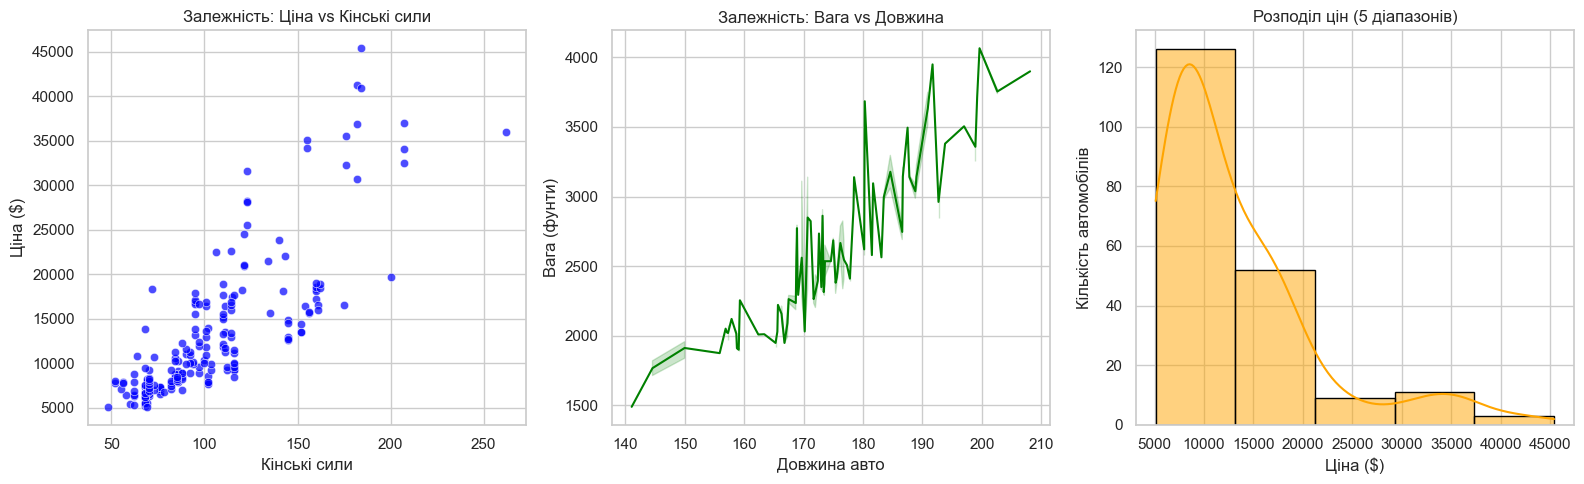

In [4]:
plt.figure(figsize=(16, 5))
sns.set_theme(style="whitegrid")

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='horsepower', y='price', color='blue', alpha=0.7)
plt.title('Залежність: Ціна vs Кінські сили')
plt.xlabel('Кінські сили')
plt.ylabel('Ціна ($)')

df_sorted = df.sort_values(by='length')
plt.subplot(1, 3, 2)
sns.lineplot(data=df_sorted, x='length', y='curb-weight', color='green')
plt.title('Залежність: Вага vs Довжина')
plt.xlabel('Довжина авто')
plt.ylabel('Вага (фунти)')

plt.subplot(1, 3, 3)
sns.histplot(df['price'], bins=5, color='orange', edgecolor='black', kde=True)
plt.title('Розподіл цін (5 діапазонів)')
plt.xlabel('Ціна ($)')
plt.ylabel('Кількість автомобілів')

plt.tight_layout()
plt.show()

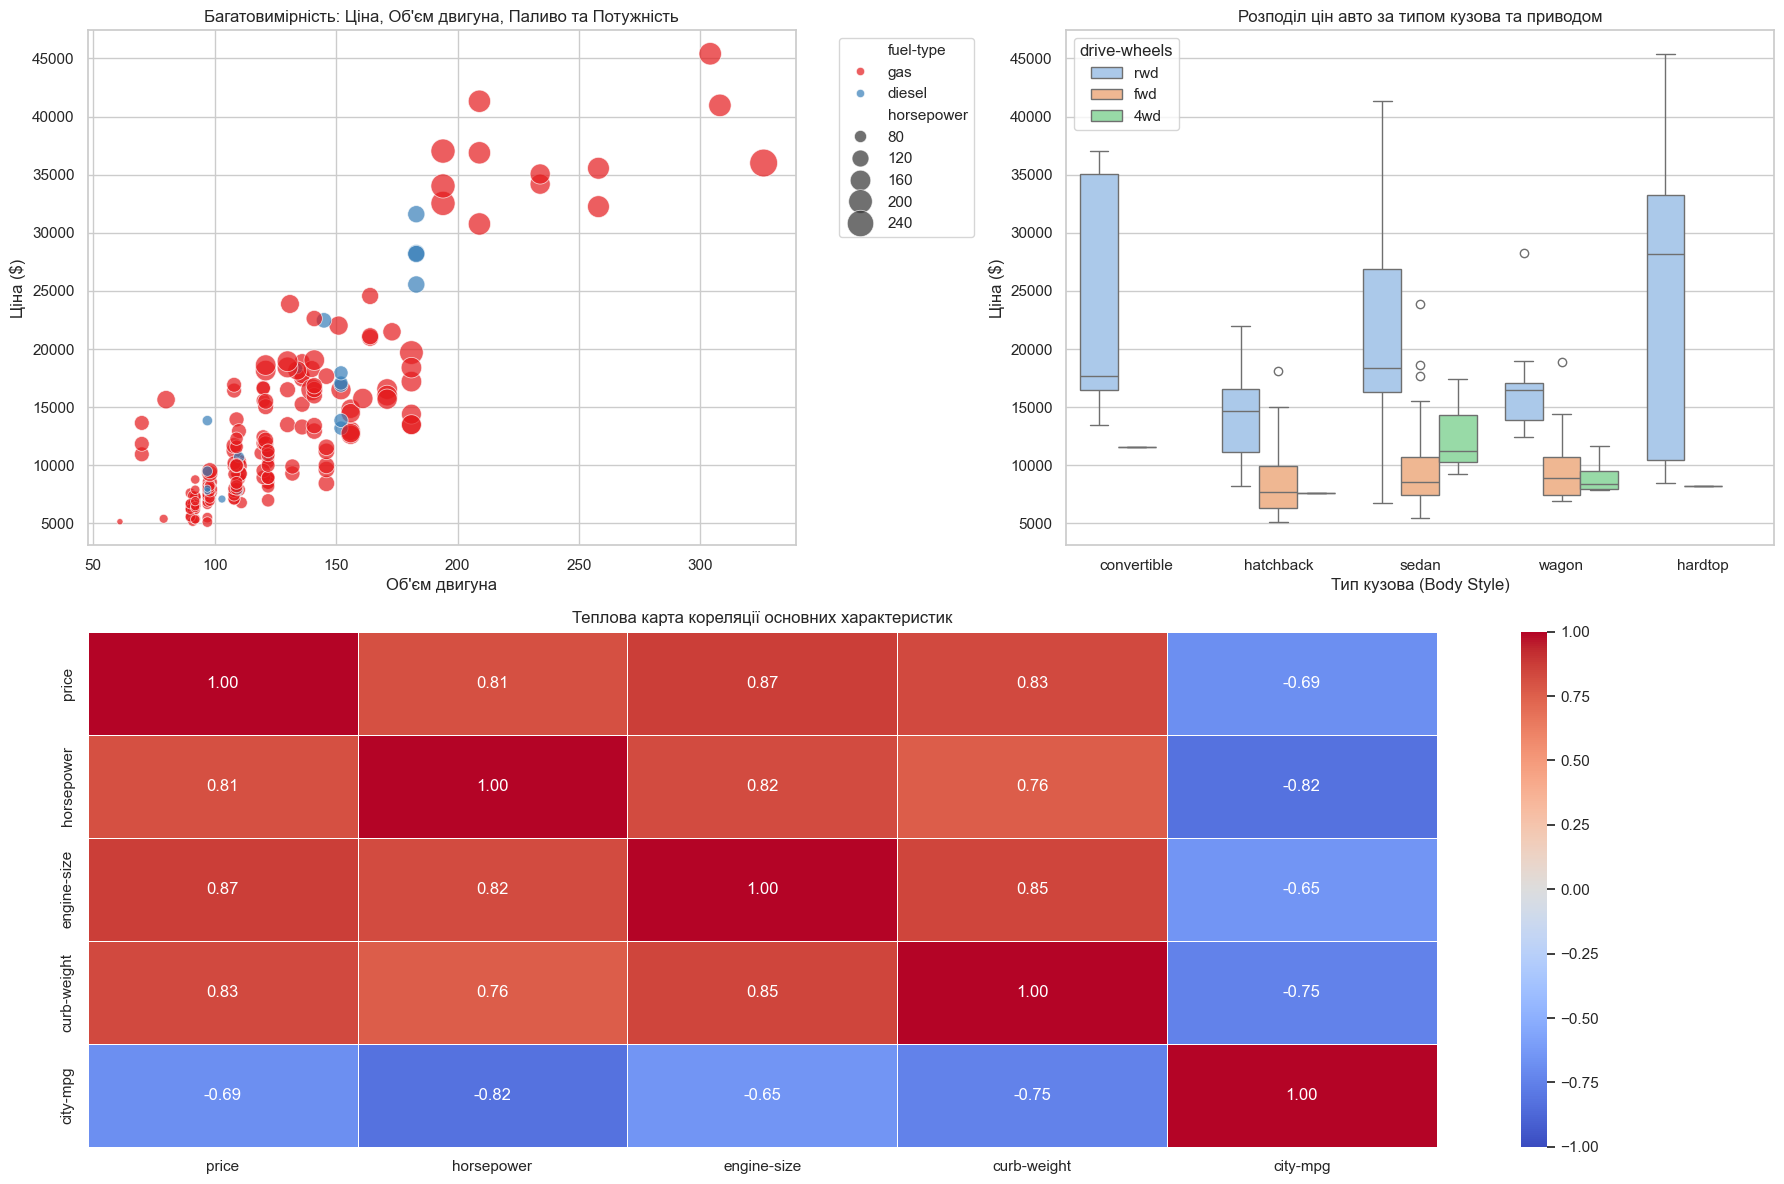

In [5]:
plt.figure(figsize=(18, 12))
sns.set_theme(style="whitegrid")

plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='engine-size', y='price', 
                hue='fuel-type', size='horsepower', sizes=(20, 400), 
                palette='Set1', alpha=0.7)
plt.title('Багатовимірність: Ціна, Об\'єм двигуна, Паливо та Потужність')
plt.xlabel('Об\'єм двигуна')
plt.ylabel('Ціна ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Виносимо легенду за графік

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='body-style', y='price', hue='drive-wheels', palette='pastel')
plt.title('Розподіл цін авто за типом кузова та приводом')
plt.xlabel('Тип кузова (Body Style)')
plt.ylabel('Ціна ($)')

plt.subplot(2, 1, 2)
cols_for_heatmap = ['price', 'horsepower', 'engine-size', 'curb-weight', 'city-mpg']
corr_matrix = df[cols_for_heatmap].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Теплова карта кореляції основних характеристик')
plt.tight_layout()
plt.show()